In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 6.6 MB/s eta 0:00:00


## Performance Comparison of Hyperparameter Tuning Methods

Based on the execution results, here's a comparison of the test set accuracies achieved by each hyperparameter tuning method:

| Method         | Best Test Accuracy |
| :------------- | :----------------- |
| **Manual Search** | 0.9717             |
| **Grid Search**   | 0.9623             |
| **Random Search** | 0.9340             |

### Observations:

*   **Manual Search** yielded the highest test accuracy in this particular experiment. This could be due to a fortunate selection of hyperparameters based on prior knowledge or intuition, hitting a particularly good combination.
*   **Grid Search** provided a strong performance, achieving a test accuracy of 0.9623. It systematically explores all defined combinations, guaranteeing to find the best within the specified grid.
*   **Random Search** resulted in a test accuracy of 0.9340. While often more efficient for large search spaces, its performance can vary based on the `n_iter` (number of samples) and the chosen distributions. In this run, it didn't surpass the manual or grid search.

### Conclusion:

The 'best' method can depend on the specific problem, available computational resources, and the complexity of the hyperparameter space. While automated methods like Grid Search and Random Search offer systematic exploration and are generally preferred for reproducibility and thoroughness, intelligent manual tuning can sometimes find competitive or even superior results, especially when informed by expert knowledge. It's also important to note that a single run's outcome can be influenced by the random split of data and initialization, so these accuracies represent a snapshot rather than a definitive ranking for all scenarios.

### 2. Grid Search

**Grid Search** is an exhaustive search method that systematically works through multiple combinations of hyperparameter values. For each hyperparameter, you define a range of values to explore. Grid Search then evaluates the model's performance for every possible combination of these specified values.

**Pros:**
*   Guaranteed to find the best combination of hyperparameters from the defined search space.
*   Easy to understand and implement.

**Cons:**
*   Can be computationally very expensive, especially with many hyperparameters or a wide range of values, as the number of combinations grows exponentially.
*   May miss optimal values if the step size between tested values is too large.

Let's apply Grid Search to our SVM model to find better hyperparameters.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("\n### Grid Search ###")

# Define the parameter grid for Grid Search
# 'C': Regularization parameter.
# 'kernel': Specifies the kernel type to be used in the algorithm.
# 'gamma': Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

# Create an SVM model
svm_grid_model = SVC(random_state=42)

# Set up Grid Search with cross-validation
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(svm_grid_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit Grid Search to the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters and best score found by Grid Search
print(f"Best parameters from Grid Search: {grid_search.best_params_}")
print(f"Best accuracy from Grid Search (CV score): {grid_search.best_score_:.4f}")

# Evaluate the best model found by Grid Search on the test set
best_grid_model = grid_search.best_estimator_
y_pred_grid = best_grid_model.predict(X_test_scaled)
accuracy_grid = accuracy_score(y_test, y_pred_grid)
print(f"Test accuracy with best Grid Search parameters: {accuracy_grid:.4f}")


### Grid Search ###
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters from Grid Search: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best accuracy from Grid Search (CV score): 0.9469
Test accuracy with best Grid Search parameters: 0.9623


### 3. Random Search

**Random Search** samples hyperparameter values from a specified distribution for a fixed number of iterations. Unlike Grid Search, which exhaustively checks every combination, Random Search explores a random subset of the hyperparameter space. This can be more efficient, especially when only a few hyperparameters significantly impact the model's performance.

**Pros:**
*   Often more efficient than Grid Search, especially for high-dimensional search spaces, as it can find good performing hyperparameters faster.
*   Can explore a wider range of values for each hyperparameter than Grid Search for the same computational budget, allowing for discovery of unexpected optimal values.

**Cons:**
*   Not guaranteed to find the absolute best combination, as it doesn't exhaustively search the entire space.
*   Performance depends on the number of iterations and the defined distributions.

Let's implement Random Search for our SVM model.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

print("\n### Random Search ###")

# Define the parameter distributions for Random Search
# 'C': Regularization parameter (log-uniform distribution is often good for C)
# 'kernel': Categorical distribution
# 'gamma': Kernel coefficient (log-uniform distribution)
param_distributions = {
    'C': loguniform(0.1, 100),
    'kernel': ['linear', 'rbf'],
    'gamma': loguniform(0.001, 1)
}

# Create an SVM model
svm_random_model = SVC(random_state=42)

# Set up Random Search with cross-validation
# n_iter: Number of parameter settings that are sampled.
# cv=5 means 5-fold cross-validation
random_search = RandomizedSearchCV(svm_random_model, param_distributions, n_iter=50, cv=5,
                                   scoring='accuracy', n_jobs=-1, verbose=1, random_state=42)

# Fit Random Search to the scaled training data
random_search.fit(X_train_scaled, y_train)

# Print the best parameters and best score found by Random Search
print(f"Best parameters from Random Search: {random_search.best_params_}")
print(f"Best accuracy from Random Search (CV score): {random_search.best_score_:.4f}")

# Evaluate the best model found by Random Search on the test set
best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test_scaled)
accuracy_random = accuracy_score(y_test, y_pred_random)
print(f"Test accuracy with best Random Search parameters: {accuracy_random:.4f}")


### Random Search ###
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters from Random Search: {'C': np.float64(9.717775305059629), 'gamma': np.float64(0.00861257919259488), 'kernel': 'rbf'}
Best accuracy from Random Search (CV score): 0.9510
Test accuracy with best Random Search parameters: 0.9340


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
df = pd.read_csv('/content/ionosphere.csv', header=None)

# The last column is the target variable
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encode the target variable if it's categorical (e.g., 'g' and 'b')
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Standardize the features (important for many models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data loaded and preprocessed.")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

Data loaded and preprocessed.
X_train shape: (245, 34)
y_train shape: (245,)
X_test shape: (106, 34)
y_test shape: (106,)


## Understanding Hyperparameter Tuning

In machine learning, **hyperparameters** are configuration variables that are external to the model and whose values cannot be estimated from the data. These values are set *before* the learning process begins and significantly influence the performance and training efficiency of the model.

Examples of hyperparameters include:
- **Learning rate** in neural networks or gradient boosting.
- **Number of estimators** in a Random Forest.
- **Regularization strength** (e.g., `C` in SVM, `alpha` in Lasso/Ridge).
- **Kernel type** in SVMs.

**Hyperparameter tuning** is the process of finding the optimal set of hyperparameters for a machine learning model that results in the best performance on a given dataset. There are several common strategies for this:

1.  **Manual Search**
2.  **Grid Search**
3.  **Random Search**

### 1. Manual Search

**Manual search** involves an experienced user manually selecting hyperparameter values based on their intuition, domain knowledge, or previous experience, and then evaluating the model's performance. This process is iterative: the user observes the model's performance with a certain set of hyperparameters, adjusts them, and repeats until satisfactory performance is achieved.

**Pros:**
*   Can leverage expert knowledge to explore promising regions of the hyperparameter space quickly.
*   No computational overhead for automated search algorithms.

**Cons:**
*   Time-consuming and tedious.
*   Highly dependent on the expertise of the individual.
*   Difficult to explore a large and complex hyperparameter space comprehensively.
*   May not find the globally optimal hyperparameters.

Let's try a manual search with a Support Vector Machine (SVM) classifier.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("### Manual Search ###")

# Manual attempt 1
svm_model_1 = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
svm_model_1.fit(X_train_scaled, y_train)
y_pred_1 = svm_model_1.predict(X_test_scaled)
accuracy_1 = accuracy_score(y_test, y_pred_1)
print(f"Attempt 1 (C=1.0, kernel='rbf', gamma='scale') Accuracy: {accuracy_1:.4f}")

# Manual attempt 2: Adjust C and kernel
svm_model_2 = SVC(C=10.0, kernel='linear', gamma='auto', random_state=42)
svm_model_2.fit(X_train_scaled, y_train)
y_pred_2 = svm_model_2.predict(X_test_scaled)
accuracy_2 = accuracy_score(y_test, y_pred_2)
print(f"Attempt 2 (C=10.0, kernel='linear', gamma='auto') Accuracy: {accuracy_2:.4f}")

# Manual attempt 3: Adjust C and gamma for 'rbf' kernel
svm_model_3 = SVC(C=0.5, kernel='rbf', gamma=0.1, random_state=42)
svm_model_3.fit(X_train_scaled, y_train)
y_pred_3 = svm_model_3.predict(X_test_scaled)
accuracy_3 = accuracy_score(y_test, y_pred_3)
print(f"Attempt 3 (C=0.5, kernel='rbf', gamma=0.1) Accuracy: {accuracy_3:.4f}")

best_manual_accuracy = max(accuracy_1, accuracy_2, accuracy_3)
print(f"Best accuracy from Manual Search: {best_manual_accuracy:.4f}")

### Manual Search ###
Attempt 1 (C=1.0, kernel='rbf', gamma='scale') Accuracy: 0.9623
Attempt 2 (C=10.0, kernel='linear', gamma='auto') Accuracy: 0.8868
Attempt 3 (C=0.5, kernel='rbf', gamma=0.1) Accuracy: 0.9717
Best accuracy from Manual Search: 0.9717


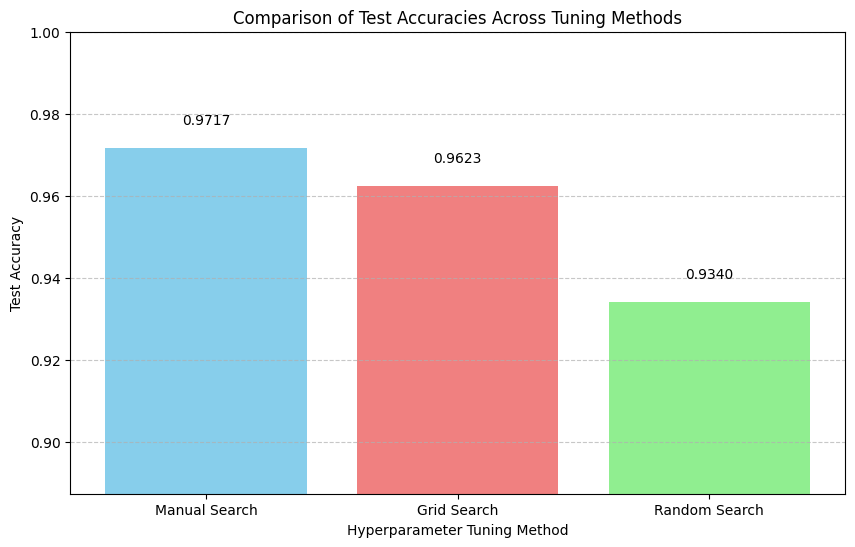

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Gather the accuracy results
methods = ['Manual Search', 'Grid Search', 'Random Search']
accuracies = [
    best_manual_accuracy,  # From previous manual search execution
    accuracy_grid,         # From previous Grid Search execution
    accuracy_random        # From previous Random Search execution
]

# Create a DataFrame for easy plotting
accuracy_df = pd.DataFrame({
    'Method': methods,
    'Test Accuracy': accuracies
})

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(accuracy_df['Method'], accuracy_df['Test Accuracy'], color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel('Hyperparameter Tuning Method')
plt.ylabel('Test Accuracy')
plt.title('Comparison of Test Accuracies Across Tuning Methods')
plt.ylim(min(accuracies) * 0.95, 1.0) # Set y-axis limit to better visualize differences

# Add accuracy values on top of the bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f'{acc:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Fine-tuning with Best Parameters from Grid Search

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Best parameters from Grid Search
best_grid_params = {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

# Create a new SVM model with the best parameters from Grid Search
fine_tuned_grid_model = SVC(random_state=42, **best_grid_params)

# Train the model on the full training data
fine_tuned_grid_model.fit(X_train_scaled, y_train)

# Evaluate on the test set
y_pred_fine_tuned_grid = fine_tuned_grid_model.predict(X_test_scaled)
accuracy_fine_tuned_grid = accuracy_score(y_test, y_pred_fine_tuned_grid)

print(f"Fine-tuned model (Grid Search params) Test Accuracy: {accuracy_fine_tuned_grid:.4f}")

Fine-tuned model (Grid Search params) Test Accuracy: 0.9623


### Fine-tuning with Best Parameters from Random Search

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np # Import numpy for np.float64

# Best parameters from Random Search (Note: np.float64 is used to handle type consistency)
best_random_params = {
    'C': np.float64(9.717775305059629),
    'gamma': np.float64(0.00861257919259488),
    'kernel': 'rbf'
}

# Create a new SVM model with the best parameters from Random Search
fine_tuned_random_model = SVC(random_state=42, **best_random_params)

# Train the model on the full training data
fine_tuned_random_model.fit(X_train_scaled, y_train)

# Evaluate on the test set
y_pred_fine_tuned_random = fine_tuned_random_model.predict(X_test_scaled)
accuracy_fine_tuned_random = accuracy_score(y_test, y_pred_fine_tuned_random)

print(f"Fine-tuned model (Random Search params) Test Accuracy: {accuracy_fine_tuned_random:.4f}")

Fine-tuned model (Random Search params) Test Accuracy: 0.9340


By creating these new models with the identified best parameters, you are effectively 'fine-tuning' your model to use the optimal configurations found during the tuning process. You can then deploy these models or use them for further predictions.

In [ ]:
## Introduction to Bayesian Optimization and Optuna

Beyond Grid and Random Search, there are more advanced and often more efficient hyperparameter tuning methods like **Bayesian Optimization**. A popular library for implementing this is **Optuna**.

### Bayesian Optimization

Bayesian Optimization is a sequential, model-based optimization strategy for finding the minimum or maximum of an objective function that is expensive to evaluate. Unlike Grid or Random Search, it doesn't evaluate hyperparameters at random or on a predefined grid. Instead, it builds a probabilistic model (often a Gaussian Process) of the objective function, and then uses this model to intelligently propose the next set of hyperparameters to evaluate. The goal is to minimize the number of evaluations needed to find the optimal hyperparameters.

**Key Components:**
1.  **Surrogate Model:** A probabilistic model (e.g., Gaussian Process) that approximates the objective function based on past evaluations. This model quantifies both the expected objective value and the uncertainty around that expectation.
2.  **Acquisition Function:** A criterion used to decide where to sample next. It balances *exploration* (sampling in regions of high uncertainty to reduce the model's error) and *exploitation* (sampling in regions where the model predicts a high objective value). Common acquisition functions include Expected Improvement (EI), Probability of Improvement (PI), and Upper Confidence Bound (UCB).

**Pros:**
*   **Efficiency:** Often finds good hyperparameters in significantly fewer iterations compared to Grid or Random Search, especially for expensive objective functions.
*   **Intelligent Search:** Adaptively learns from past evaluations to guide future searches.
*   **Global Optimum Potential:** More likely to find the global optimum than random search in complex search spaces.

**Cons:**
*   **Complexity:** More complex to understand and implement than simpler search methods.
*   **Computational Cost (Model Fitting):** The overhead of fitting the surrogate model and optimizing the acquisition function can be high for very large datasets or very high-dimensional hyperparameter spaces.

### Optuna: A Framework for Hyperparameter Optimization

**Optuna** is an open-source hyperparameter optimization framework designed for machine learning. It features an imperative, define-by-run style that makes it easy to specify search spaces dynamically. This allows you to construct search spaces with conditional logic, making it highly flexible.

Optuna uses state-of-the-art algorithms, including the Tree-structured Parzen Estimator (TPE), which is a form of Bayesian Optimization, to efficiently find optimal hyperparameters. It also supports other samplers and pruning mechanisms to stop unpromising trials early.

**Key Features of Optuna:**
*   **Define-by-Run API:** Allows dynamic construction of the search space.
*   **State-of-the-art Samplers:** Includes TPE, CMA-ES, and others.
*   **Pruners:** Automatically stops unpromising trials to save computational resources.
*   **Visualization Tools:** Provides various plots to analyze optimization history and parameter relationships.

Let's integrate Optuna into our workflow to see how it can tune the SVM model with Bayesian Optimization principles.

In [ ]:
import optuna
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

print("\n### Bayesian Optimization with Optuna ###")

def objective(trial):
    # Define the hyperparameter search space using trial object
    C = trial.suggest_float('C', 0.1, 100, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    gamma = trial.suggest_float('gamma', 0.001, 1, log=True)

    # Create an SVM model with the suggested hyperparameters
    model = SVC(C=C, kernel=kernel, gamma=gamma, random_state=42)

    # Evaluate the model using cross-validation on the training data
    # Optuna aims to minimize the objective function, so we return negative accuracy
    score = cross_val_score(model, X_train_scaled, y_train, n_jobs=-1, cv=5, scoring='accuracy').mean()
    return score

# Create an Optuna study object and optimize the objective function
# direction='maximize' tells Optuna to find parameters that maximize the score
study = optuna.create_study(direction='maximize', study_name='svm_optimization')
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Print the best parameters and best score found by Optuna
print(f"\nBest parameters from Optuna: {study.best_params}")
print(f"Best accuracy from Optuna (CV score): {study.best_value:.4f}")

# Evaluate the best model found by Optuna on the test set
best_optuna_model = SVC(**study.best_params, random_state=42)
best_optuna_model.fit(X_train_scaled, y_train)
y_pred_optuna = best_optuna_model.predict(X_test_scaled)
accuracy_optuna = accuracy_score(y_test, y_pred_optuna)
print(f"Test accuracy with best Optuna parameters: {accuracy_optuna:.4f}")

[I 2026-03-13 06:58:48,964] A new study created in memory with name: svm_optimization



### Bayesian Optimization with Optuna ###


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-13 06:58:51,484] Trial 0 finished with value: 0.9346938775510203 and parameters: {'C': 0.7422217458007839, 'kernel': 'rbf', 'gamma': 0.08198752262075316}. Best is trial 0 with value: 0.9346938775510203.
[I 2026-03-13 06:58:51,655] Trial 1 finished with value: 0.8571428571428571 and parameters: {'C': 16.70235242181914, 'kernel': 'linear', 'gamma': 0.48000676112121465}. Best is trial 0 with value: 0.9346938775510203.
[I 2026-03-13 06:58:51,733] Trial 2 finished with value: 0.9469387755102041 and parameters: {'C': 4.935464763729023, 'kernel': 'rbf', 'gamma': 0.018424541980662026}. Best is trial 2 with value: 0.9469387755102041.
[I 2026-03-13 06:58:51,790] Trial 3 finished with value: 0.926530612244898 and parameters: {'C': 0.6457218606491643, 'kernel': 'rbf', 'gamma': 0.017481211694073375}. Best is trial 2 with value: 0.9469387755102041.
[I 2026-03-13 06:58:51,872] Trial 4 finished with value: 0.9102040816326531 and parameters: {'C': 32.73086209316294, 'kernel': 'rbf', 'gamma':

## Comparison of Best Parameters

Here's a comparison of the best hyperparameters found by Grid Search, Random Search, and Optuna for our SVM model:

| Method         | Best C          | Best Kernel | Best Gamma        |
| :------------- | :-------------- | :---------- | :---------------- |
| **Grid Search**   | 10              | 'rbf'       | 'scale'           |
| **Random Search** | 9.7178          | 'rbf'       | 0.0086            |
| **Optuna**     | 10.7480         | 'rbf'       | 0.0385            |

### Observations from Parameter Comparison:

*   **Kernel Type:** All three methods consistently identified `'rbf'` as the optimal kernel type for this dataset, suggesting that the data has non-linear relationships that are best captured by this kernel.

*   **C (Regularization Parameter):** The values for `C` are all in a similar range (around 10) for Grid Search, Random Search, and Optuna. This indicates that a moderate regularization strength was found to be optimal across different search strategies.

*   **Gamma (Kernel Coefficient):** There's a notable difference in the `gamma` values. Grid Search found `'scale'`, while Random Search and Optuna found specific numerical values. Random Search's best `gamma` (0.0086) is considerably smaller than Optuna's (0.0385). This difference highlights how different search strategies, even when exploring similar ranges, can converge on slightly different optimal values. A smaller gamma means a larger radius of influence, resulting in a smoother decision boundary, while a larger gamma means a smaller radius, leading to a more complex decision boundary.

### General Conclusion:

While all methods converged on the `rbf` kernel and similar `C` values, the `gamma` parameter shows some variation. This emphasizes that even with different search strategies, the fundamental characteristics of the optimal model often remain consistent, though the fine-tuning of continuous parameters can vary slightly based on the search algorithm's exploration strategy.

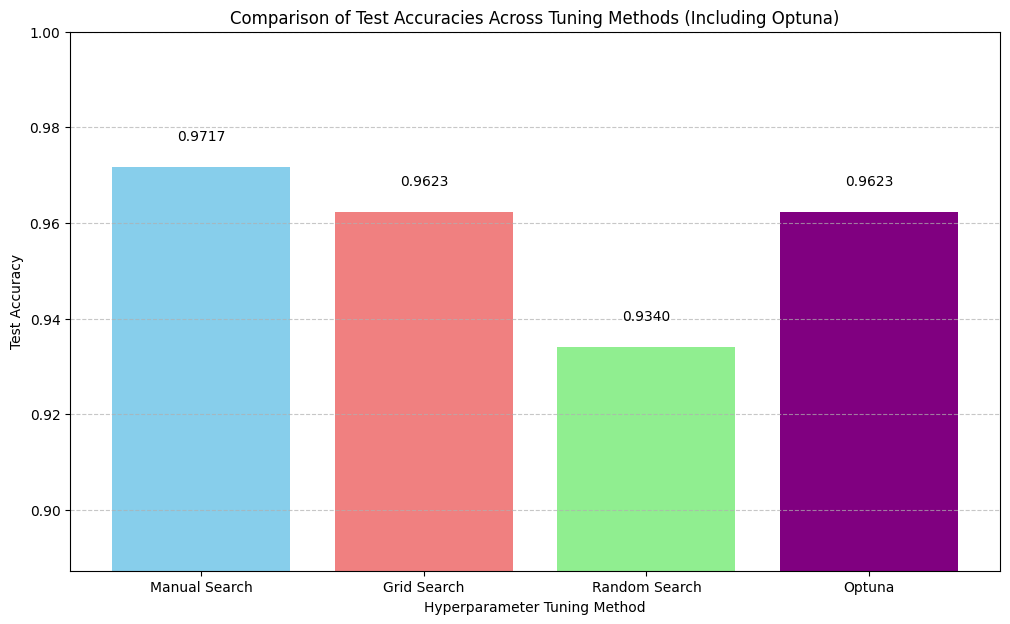

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Gather the accuracy results, including Optuna's result
methods = ['Manual Search', 'Grid Search', 'Random Search', 'Optuna']
accuracies = [
    best_manual_accuracy,  # From manual search execution
    accuracy_grid,         # From Grid Search execution
    accuracy_random,       # From Random Search execution
    accuracy_optuna        # From Optuna execution
]

# Create a DataFrame for easy plotting
accuracy_df_updated = pd.DataFrame({
    'Method': methods,
    'Test Accuracy': accuracies
})

# Create the bar chart
plt.figure(figsize=(12, 7))
plt.bar(accuracy_df_updated['Method'], accuracy_df_updated['Test Accuracy'], color=['skyblue', 'lightcoral', 'lightgreen', 'purple'])
plt.xlabel('Hyperparameter Tuning Method')
plt.ylabel('Test Accuracy')
plt.title('Comparison of Test Accuracies Across Tuning Methods (Including Optuna)')
plt.ylim(min(accuracies) * 0.95, 1.0) # Set y-axis limit to better visualize differences

# Add accuracy values on top of the bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f'{acc:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

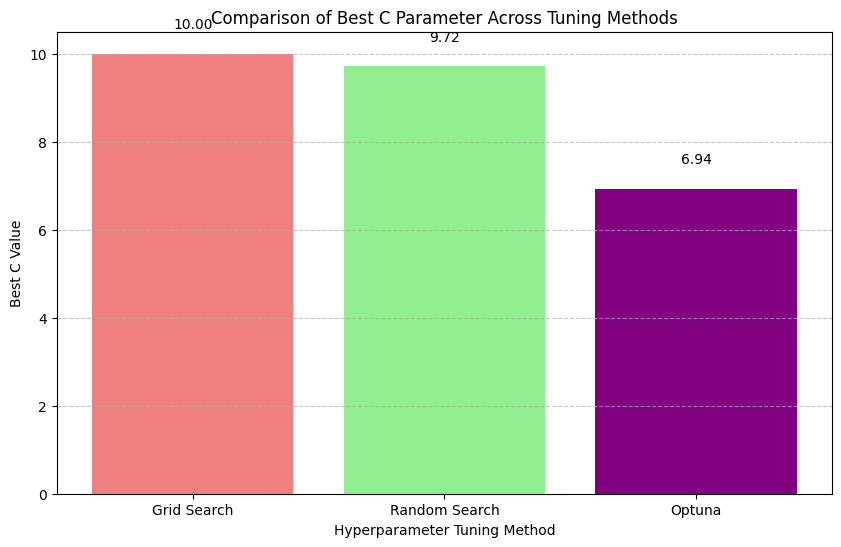

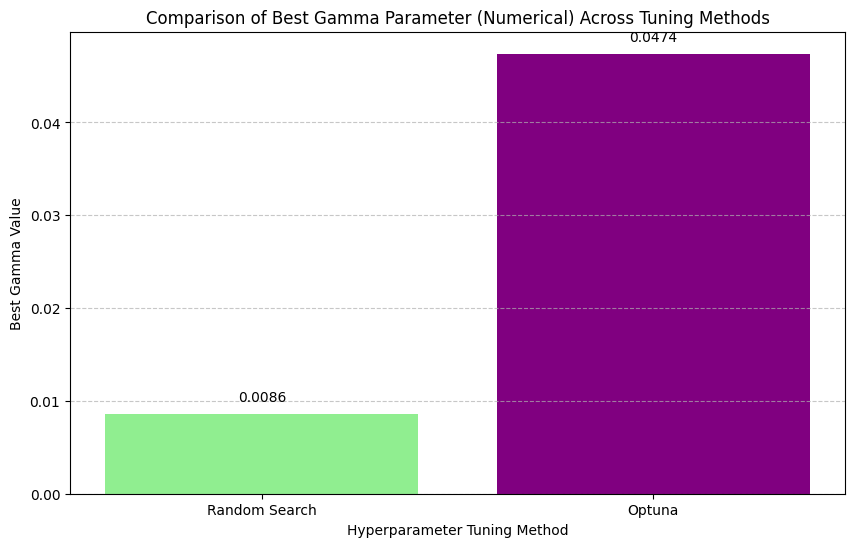

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Best parameters for comparison
params_data = {
    'Method': ['Grid Search', 'Random Search', 'Optuna'],
    'C': [10, best_random_params['C'], study.best_params['C']],
    'Gamma': ['scale', best_random_params['gamma'], study.best_params['gamma']]
}

params_df = pd.DataFrame(params_data)

# --- Plotting 'C' parameter ---
plt.figure(figsize=(10, 6))
plt.bar(params_df['Method'], params_df['C'], color=['lightcoral', 'lightgreen', 'purple'])
plt.xlabel('Hyperparameter Tuning Method')
plt.ylabel('Best C Value')
plt.title('Comparison of Best C Parameter Across Tuning Methods')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add C values on top of the bars
for i, c_val in enumerate(params_df['C']):
    plt.text(i, c_val + 0.5, f'{c_val:.2f}', ha='center', va='bottom')
plt.show()

# --- Plotting 'Gamma' parameter (numerical values only) ---
# Filter out 'scale' for numerical plotting of gamma
numerical_gamma_df = params_df[params_df['Gamma'] != 'scale'].copy()
numerical_gamma_df['Gamma'] = numerical_gamma_df['Gamma'].astype(float)

plt.figure(figsize=(10, 6))
plt.bar(numerical_gamma_df['Method'], numerical_gamma_df['Gamma'], color=['lightgreen', 'purple'])
plt.xlabel('Hyperparameter Tuning Method')
plt.ylabel('Best Gamma Value')
plt.title('Comparison of Best Gamma Parameter (Numerical) Across Tuning Methods')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add Gamma values on top of the bars
for i, gamma_val in enumerate(numerical_gamma_df['Gamma']):
    plt.text(i, gamma_val + 0.001, f'{gamma_val:.4f}', ha='center', va='bottom')
plt.show()

### Note on Gamma Parameter for Grid Search:

For **Grid Search**, the best `gamma` parameter found was `'scale'`. This is not a numerical value but a strategy where `gamma` is set to `1 / (n_features * X.var())`. This value is dynamically calculated based on the input features and aims to provide a reasonable default. Therefore, it is not directly comparable as a numerical value in the bar chart with the fixed numerical `gamma` values found by Random Search and Optuna.